# Convolution Neural Neuwork


### Một số lớp cơ bản trong CNN

#### **Dense**

Cú pháp:
```python
layer = Dense(units [, activation, use_bias, kernel_initializer, bias_initializer])
```

Hàm `Dense()` khởi tạo một lớp fully connected trong mạng neural.

Hàm có 1 đối số bắt buộc:
- `units`: Số lượng neuron trong lớp (ví dụ: 64, 128)

Các đối số tùy chọn khác:
- `activation`: Hàm kích hoạt sử dụng, ví dụ 'relu', 'sigmoid', 'softmax'  
- `use_bias`: Có dùng thêm bias không (mặc định là True)
- `kernel_initializer`: Cách khởi tạo trọng số ban đầu (ví dụ: 'he_normal', 'glorot_uniform')  
- `bias_initializer`: Cách khởi tạo bias (mặc định 'zeros')

#### **Dropout**
Cú pháp
```python
layer = Dropout(rate [, noise_shape, seed])
```
Hàm `Dropout()` giúp giảm overfitting bằng cách tắt ngẫu nhiên các neuron.

Hàm có 1 đối số bắt buộc:
- `rate`: Tỷ lệ các neuron bị tắt trong mỗi bước huấn luyện (float từ 0.0 đến 1.0)

Các đối số tùy chọn khác:
- `noise_shape`: Hình dạng của noise (thường giữ nguyên)
- `seed`: Giá trị khởi tạo random (giúp đảm bảo kết quả tái lặp)


#### **Conv2D**
Cú pháp
```python
layer = Conv2D(filters, kernel_size[, strides, padding, activation, use_bias, input_shape])
```
Hàm `Conv2D()` tạo ra một lớp tích chập 2 chiều, thường dùng trong xử lý ảnh.

Hàm có 2 đối số bắt buộc:
1. `filters`: Số lượng bộ lọc (số kênh đầu ra sau tích chập)
2. `kernel_size`: Kích thước kernel (ví dụ: (3, 3))

Các đối số tùy chọn khác:
- `strides`: Bước di chuyển kernel (mặc định là (1, 1))
- `padding`: 'valid' (không padding) hoặc 'same' (padding sao cho đầu ra không đổi kích thước)
- `activation`: Hàm kích hoạt (ví dụ: 'relu')
- `use_bias`: Có dùng bias hay không (mặc định True)
- `input_shape`: Hình dạng đầu vào, dạng (height, width, channels) – chỉ cần khai báo ở lớp đầu tiên

#### **MaxPooling2D**
Cú pháp 
```python
layer = MaxPooling2D([pool_size, strides, padding])
```
Hàm `MaxPooling2D()` thực hiện lấy giá trị lớn nhất trong từng vùng con của ảnh đầu vào.

Đối số tùy chọn:
- `pool_size`: Kích thước vùng pooling, mặc định (2, 2)
- `strides`: Bước nhảy khi di chuyển vùng pooling (mặc định bằng `pool_size`)
- `padding`: 'valid' (không padding) hoặc 'same' (giữ nguyên kích thước)

#### **Flatten**
Cú pháp
```python
layer = Flatten()
```
Lớp `Flatten()` biến tensor đầu vào nhiều chiều (như 2D, 3D) thành vector 1D

### Xây dựng Mô hình với Sequential API và Functional API

#### **Sequential API**
- Dễ sử dụng
- Các lớp được xếp tuyến tính (layer chồng layer)
- Phù hợp với mạng đơn luồng

#### Xây dựng model nhận diện chữ viết tay
- Sử dụng bộ dữ liệu chữ số viết tay có đánh nhãn với kích thước ảnh là (28, 28, 1) của MNIST

##### Kiến trúc mô hình


In [1]:
# 1. Thêm các thư viện cần thiết
# type: ignore
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers   import Conv2D, MaxPooling2D
from tensorflow.keras.utils    import to_categorical
from tensorflow.keras.datasets import mnist

In [2]:
# 2. Load dữ liệu MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_val, y_val = X_train[50000:60000,:], y_train[50000:60000]
X_train, y_train = X_train[:50000,:], y_train[:50000]
print(X_train.shape)

(50000, 28, 28)


In [3]:
# 3. Reshape lại dữ liệu cho đúng kích thước mà keras yêu cầu
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_val   = X_val.reshape(X_val.shape[0], 28, 28, 1)
X_test  = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [4]:
# 4. One hot encoding label (Y)
Y_train = to_categorical(y_train, num_classes=10)
Y_val   = to_categorical(y_val,   num_classes=10)
Y_test  = to_categorical(y_test,  num_classes=10)
print('Dữ liệu y ban đầu ', y_train[0])
print('Dữ liệu y sau one-hot encoding ',Y_train[0])

Dữ liệu y ban đầu  5
Dữ liệu y sau one-hot encoding  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [5]:
# 5. Định nghĩa model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='sigmoid', input_shape=(28,28,1)))
model.add(Conv2D(32, (3, 3), activation='sigmoid'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))

In [6]:
# 6. Compile model, chỉ rõ hàm loss_function nào được sử dụng, phương thức
# dùng để tối ưu hàm loss function.
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
# 7. Thực hiện train model với data
H = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=32, epochs=10, verbose=1)

Epoch 1/10


1563/1563 [==============================] - 22s 13ms/step - loss: 0.2951 - accuracy: 0.9152 - val_loss: 0.0704 - val_accuracy: 0.9814
Epoch 2/10
1563/1563 [==============================] - 21s 13ms/step - loss: 0.0589 - accuracy: 0.9832 - val_loss: 0.0499 - val_accuracy: 0.9860
Epoch 3/10
1563/1563 [==============================] - 21s 13ms/step - loss: 0.0363 - accuracy: 0.9893 - val_loss: 0.0479 - val_accuracy: 0.9865
Epoch 4/10
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0242 - accuracy: 0.9934 - val_loss: 0.0438 - val_accuracy: 0.9881
Epoch 5/10
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0162 - accuracy: 0.9959 - val_loss: 0.0391 - val_accuracy: 0.9882
Epoch 6/10
1563/1563 [==============================] - 22s 14ms/step - loss: 0.0119 - accuracy: 0.9969 - val_loss: 0.0404 - val_accuracy: 0.9891
Epoch 7/10
1563/1563 [==============================] - 21s 13ms/step - loss: 0.0081 - accuracy: 0.9980 - val_loss: 0.0455

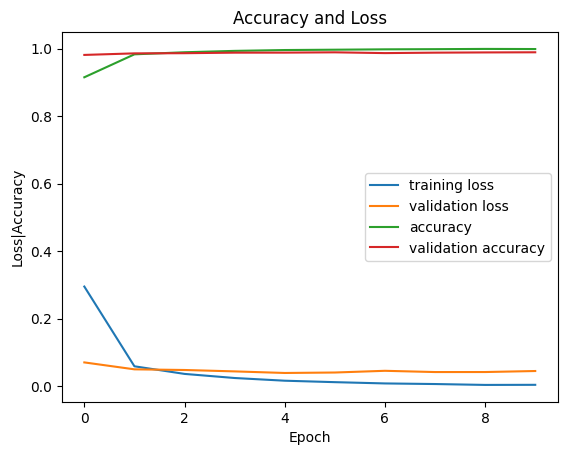

In [8]:
# 8. Vẽ đồ thị loss, accuracy của training set và validation set
fig = plt.figure()
numOfEpoch = 10

plt.plot(np.arange(0, numOfEpoch), H.history['loss'], label='training loss')
plt.plot(np.arange(0, numOfEpoch), H.history['val_loss'], label='validation loss')
plt.plot(np.arange(0, numOfEpoch), H.history['accuracy'], label='accuracy')
plt.plot(np.arange(0, numOfEpoch), H.history['val_accuracy'], label='validation accuracy')
plt.title('Accuracy and Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss|Accuracy')
plt.legend()

In [9]:
# 9. Đánh giá model với dữ liệu test set
score = model.evaluate(X_test, Y_test, verbose=0)
print(score)

[0.03619460016489029, 0.9890000224113464]


1/1 [==============================] - 0s 118ms/step
Giá trị dự đoán:  7


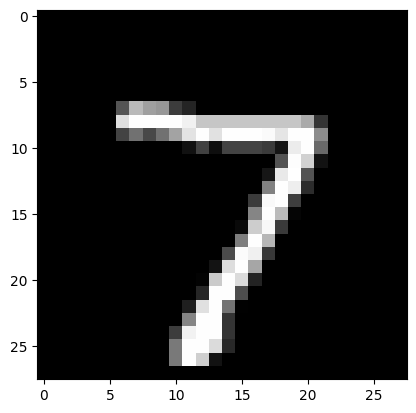

In [10]:
# 10. Dự đoán ảnh
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
y_predict = model.predict(X_test[0].reshape(1,28,28,1))
print('Giá trị dự đoán: ', np.argmax(y_predict))

#### **Functional API**
- Linh hoạt hơn, cho phép tạo mạng phức tạp (nhiều nhánh, chia/xuất nhiều đầu ra)
- Khai báo lớp như một biểu đồ

In [18]:
# type: ignore
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

##### Khai báo cấu trúc model

In [19]:
# Input layer
inputs = Input(shape=(28, 28, 1))

# Convolutional layers
x = Conv2D(32, (3, 3), activation='sigmoid')(inputs)
x = Conv2D(32, (3, 3), activation='sigmoid')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Flatten and Dense layers
x = Flatten()(x)
x = Dense(128, activation='sigmoid')(x)
outputs = Dense(10, activation='softmax')(x)

# Define model
model = Model(inputs=inputs, outputs=outputs)

In [20]:
# 6. Compile model, chỉ rõ hàm loss_function nào được sử dụng, phương thức
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
# 7. Thực hiện train model với data
H = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=32, epochs=10, verbose=1)

Epoch 1/10
1563/1563 [==============================] - 22s 14ms/step - loss: 0.2528 - accuracy: 0.9279 - val_loss: 0.0833 - val_accuracy: 0.9776
Epoch 2/10
1563/1563 [==============================] - 21s 13ms/step - loss: 0.0669 - accuracy: 0.9802 - val_loss: 0.0619 - val_accuracy: 0.9835
Epoch 3/10
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0429 - accuracy: 0.9879 - val_loss: 0.0475 - val_accuracy: 0.9860
Epoch 4/10
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0299 - accuracy: 0.9912 - val_loss: 0.0510 - val_accuracy: 0.9858
Epoch 5/10
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0208 - accuracy: 0.9943 - val_loss: 0.0492 - val_accuracy: 0.9860
Epoch 6/10
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0146 - accuracy: 0.9963 - val_loss: 0.0434 - val_accuracy: 0.9880
Epoch 7/10
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0098 - accuracy: 0.9976 - val_loss: 0.0452 -

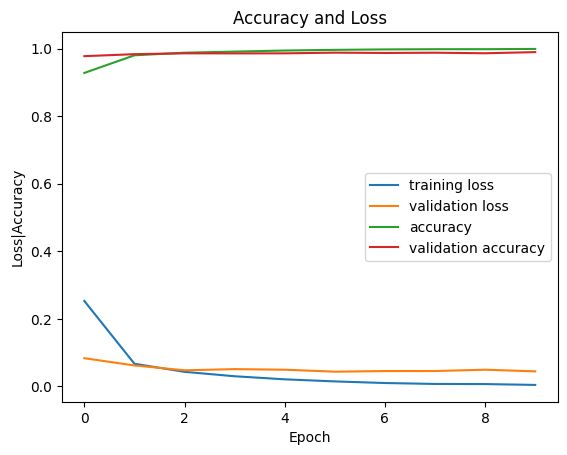

In [22]:
# 8. Vẽ đồ thị loss, accuracy của training set và validation set
fig = plt.figure()
numOfEpoch = 10

plt.plot(np.arange(0, numOfEpoch), H.history['loss'], label='training loss')
plt.plot(np.arange(0, numOfEpoch), H.history['val_loss'], label='validation loss')
plt.plot(np.arange(0, numOfEpoch), H.history['accuracy'], label='accuracy')
plt.plot(np.arange(0, numOfEpoch), H.history['val_accuracy'], label='validation accuracy')
plt.title('Accuracy and Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss|Accuracy')
plt.legend()

In [23]:
# 9. Đánh giá model với dữ liệu test set
score = model.evaluate(X_test, Y_test, verbose=0)
print(score)

[0.0343145988881588, 0.9897000193595886]


1/1 [==============================] - 0s 54ms/step
Giá trị dự đoán:  7


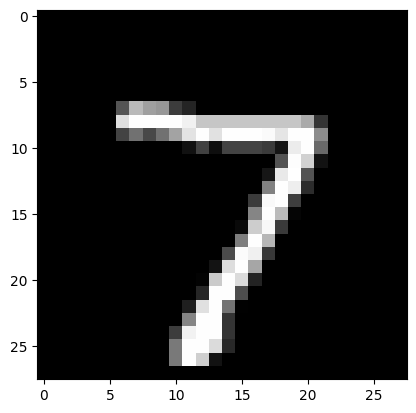

In [24]:
# 10. Dự đoán ảnh
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
y_predict = model.predict(X_test[0].reshape(1,28,28,1))
print('Giá trị dự đoán: ', np.argmax(y_predict))